<a href="https://colab.research.google.com/github/MelikeE4/birimdonusturme/blob/master/10c_goruntuye_nesne_ekleme1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sanal Aksesuar Uygulaması: YOLO ile Gerçek Zamanlı Yüz Tespiti ve Üst Üste Bindirme

Bu notebook, canlı kamera görüntünüze sanal gözlük veya takı gibi aksesuarları eklemek için bir rehber görevi görecektir. Bu işlemi gerçekleştirmek için aşağıdaki adımları izleyeceğiz:

1.  **Gerekli Kütüphanelerin Kurulumu**: OpenCV ve Ultralytics YOLOv8 gibi kütüphaneleri yükleyeceğiz.
2.  **YOLO Modelini Yükleme**: Yüz tespiti için önceden eğitilmiş bir YOLO modelini indireceğiz.
3.  **Web Kamerasına Erişim**: Canlı video akışını yakalayacağız.
4.  **Yüz Tespiti**: Yakalanan çerçevelerde yüzleri tespit etmek için YOLO modelini kullanacağız.
5.  **Aksesuarı Üst Üste Bindirme**: Tespit edilen yüz konumlarına sanal aksesuar görüntüsünü yerleştireceğiz.

### Adım 1: Gerekli Kütüphanelerin Kurulumu

In [1]:
# Gerekli kütüphaneleri yüklüyoruz. 'ultralytics' YOLO modelleri için, 'opencv-python' ise görüntü işleme ve kamera erişimi için kullanılır.
!pip install opencv-python ultralytics -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.2 MB/s eta 0:00:00


### Adım 2: YOLO Modelini Yükleme ve Yüz Tespiti için Hazırlık

Ultralytics kütüphanesi ile önceden eğitilmiş bir YOLO modelini kolayca yükleyebiliriz. Yüz tespiti için `yolov8n-face.pt` modelini kullanacağız. Bu model, insan yüzlerini yüksek doğrulukla tespit etmek için optimize edilmiştir.

In [6]:
import cv2
from ultralytics import YOLO
import numpy as np
import os

# YOLOv8n modelini yüklüyoruz.
# Standart model otomatik olarak indirilecektir.
model = YOLO('yolov8n.pt')

print("YOLOv8n modeli başarıyla yüklendi.")

YOLOv8n modeli başarıyla yüklendi.


### Adım 3: Web Kamerasına Erişim ve Gerçek Zamanlı Yüz Tespiti

Bu adımda, web kameranızdan video akışını yakalayacak, her bir karede yüz tespiti yapacak ve tespit edilen yüzleri bir çerçeve ile işaretleyerek görüntüyü göstereceğiz. Colab ortamında doğrudan `cv2.imshow` kullanmak zor olduğundan, video akışını `IPython.display` kullanarak web arayüzünde göstermenin bir yolu olan `cv2_imshow` (Google Colab'a özel) veya `base64` dönüşümü ile bir görüntü bileşenini güncellemeyi tercih edeceğiz. Ancak, canlı akış için özel bir setup gereklidir.

**Önemli Not**: Google Colab'da doğrudan `cv2.VideoCapture(0)` ile canlı web kamerasına erişim ve sürekli akış gösterme, genellikle tarayıcı tabanlı kısıtlamalar nedeniyle dış bir arayüz (ngrok gibi) olmadan sorunlu olabilir. Basit bir gösterim için fotoğraf çekip üzerinde işlem yapabilir veya daha gelişmiş canlı akış çözümleri için Colab dışı bir ortam (yerel Python kurulumu) düşünebilirsiniz.

Aşağıdaki kod bloğu, canlı akış yerine, kameradan bir *anlık görüntü* alıp üzerinde yüz tespiti yapmayı dener. Canlı akış için daha fazla yapılandırma gereklidir. Bu örneği çalıştırdığınızda, Colab'ın kameranıza erişim izni isteyebileceğini unutmayın.

In [3]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

try:
  filename = take_photo()
  print(f'Saved to {filename}')

  # Resmi OpenCV ile yüklüyoruz
  img_np = cv2.imread(filename)

  # YOLO ile yüz tespiti yapıyoruz
  results = model(img_np)

  # Tespit edilen yüzleri çiziyoruz
  for r in results:
      boxes = r.boxes
      for box in boxes:
          # Bounding box koordinatları
          x1, y1, x2, y2 = map(int, box.xyxy[0])
          cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 2) # Yeşil dikdörtgen çiz

  # İşlenmiş görüntüyü görüntülüyoruz
  # Colab'da görüntüyü göstermek için 'cv2_imshow' veya Base64 dönüşümü kullanılır.
  # cv2_imshow mevcut değilse manuel olarak dönüştürmek gerekir.
  try:
      from google.colab.patches import cv2_imshow
      cv2_imshow(img_np)
  except ImportError:
      # cv2_imshow yoksa, görüntüyü base64'e dönüştürüp gösteririz
      _, encoded_img = cv2.imencode('.jpg', img_np)
      display(Image(data=b64encode(encoded_img).decode('ascii')))

except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not allow access
  print(str(err))
  print("Web kameranıza erişimde bir sorun oluştu veya izin verilmedi.")
  print("Lütfen bir resim dosyası sağlayarak devam edebilirsiniz.")

<IPython.core.display.Javascript object>

NotAllowedError: The request is not allowed by the user agent or the platform in the current context.
Web kameranıza erişimde bir sorun oluştu veya izin verilmedi.
Lütfen bir resim dosyası sağlayarak devam edebilirsiniz.


Yukarıdaki kod, web kameranızdan bir fotoğraf çeker ve bu fotoğraf üzerinde yüz tespiti yapar. Canlı akış yerine anlık bir görüntü işler.

### Sonraki Adımlar:

Şimdi bir yüz tespit ettiğimize göre, bir sonraki adım bu yüzlerin üzerine gözlük veya takı gibi bir aksesuarı yerleştirmek olacak. Bunun için aksesuarları bir resim dosyası olarak sağlamanız gerekecek.

### Adım 4: Aksesuarı (Gözlük) Üst Üste Bindirme Fonksiyonu

Bu fonksiyon, şeffaf bir PNG görüntüsünü ana görüntü üzerine belirli bir koordinata yerleştirir.

In [21]:
def overlay_transparent(background, overlay, x, y, overlay_size=None):
    """
    Şeffaf bir PNG görüntüsünü (overlay), arka plan (background) üzerine bindirir.
    """
    background_width, background_height = background.shape[1], background.shape[0]

    if overlay_size:
        overlay = cv2.resize(overlay, overlay_size)

    if x >= background_width or y >= background_height:
        return background

    h, w = overlay.shape[0], overlay.shape[1]
    if x + w > background_width:
        w = background_width - x
        overlay = overlay[:, :w]

    if y + h > background_height:
        h = background_height - y
        overlay = overlay[:h]

    if overlay.shape[2] < 4:
        # Eğer resim şeffaf değilse (alpha kanalı yoksa), direkt yapıştır
        background[y:y+h, x:x+w] = overlay[0:h, 0:w]
    else:
        # Şeffaflık işlemleri
        overlay_image = overlay[..., :3]
        mask = overlay[..., 3:] / 255.0

        background[y:y+h, x:x+w] = (1.0 - mask) * background[y:y+h, x:x+w] + mask * overlay_image

    return background

### Adım 5: Gözlüğü Uygulama

Lütfen sol taraftaki dosya menüsünden gözlük resmini yükleyin ve adını `glasses.png` yapın. Sonra aşağıdaki kodu çalıştırın.

<IPython.core.display.Javascript object>

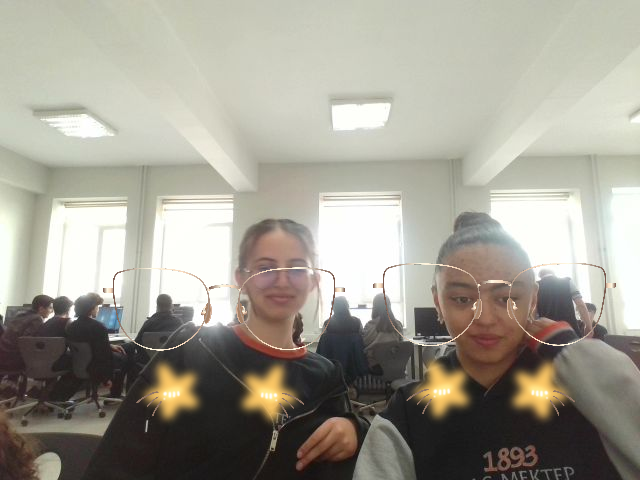

In [30]:
import os

# Dosya yollarını tanımlıyoruz
glasses_path = '/content/glasses.png'
# Dosya adını sistemdeki mevcut dosya ile güncelledik
whiskers_path = '/content/kedibiyigi.png'

try:
    # Aksesuarları yükle
    glasses = cv2.imread(glasses_path, cv2.IMREAD_UNCHANGED)
    whiskers = cv2.imread(whiskers_path, cv2.IMREAD_UNCHANGED)

    if glasses is None or whiskers is None:
        missing = []
        if glasses is None: missing.append('glasses.png')
        if whiskers is None: missing.append('kedibiyigi.png')
        print(f"Hata: Şu dosyalar bulunamadı: {', '.join(missing)}")
    else:
        # Fotoğraf çek
        filename = take_photo()
        img = cv2.imread(filename)

        # YOLO tespiti
        results = model(img, conf=0.5, verbose=False)

        for r in results:
            for box in r.boxes:
                conf = box.conf[0]
                # Sınıf 0 (insan/yüz) ve belirli bir güven eşiği
                if int(box.cls[0]) == 0 and conf > 0.6:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    face_width = x2 - x1
                    face_height = y2 - y1

                    if face_width < 100:
                        continue

                    # 1. GÖZLÜK: Yüz genişliğinin %95'i, göz hizası (%35)
                    gw = int(face_width * 0.95)
                    gh = int(gw * glasses.shape[0] / glasses.shape[1])
                    gx = x1 + int((face_width - gw) / 2)
                    gy = y1 + int(face_height * 0.35) - int(gh / 2)
                    img = overlay_transparent(img, glasses, gx, gy, (gw, gh))

                    # 2. BIYIK: Yüz genişliğinin %80'i, burun/yanak hizası (%65)
                    ww = int(face_width * 0.80)
                    wh = int(ww * whiskers.shape[0] / whiskers.shape[1])
                    wx = x1 + int((face_width - ww) / 2)
                    wy = y1 + int(face_height * 0.65) - int(wh / 2)
                    img = overlay_transparent(img, whiskers, wx, wy, (ww, wh))

        # Sonucu göster
        try:
            from google.colab.patches import cv2_imshow
            cv2_imshow(img)
        except:
            _, encoded_img = cv2.imencode('.jpg', img)
            display(Image(data=b64encode(encoded_img).decode('ascii')))

except Exception as e:
    print(f"İşlem sırasında hata: {e}")